<a href="https://colab.research.google.com/github/cccontre1/Tarea_final_DIADM_curso1/blob/main/Arboles_Grupo4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Taller: Árboles de Decisión y Explicabilidad

## 1. Introducción

Los árboles de decisión son uno de los modelos más simples y a la vez más interpretables en el aprendizaje automático. Funcionan como un conjunto de reglas clínicas: cada nodo representa una pregunta binaria sobre una variable (por ejemplo, ¿glucosa > 126 mg/dl?), y al descender por las ramas se llega a una predicción final ￼.

Su atractivo principal es la transparencia: permiten entender con claridad por qué un paciente fue clasificado como “sano” o “enfermo”. Por ejemplo:
  * Si glucosa > 126 mg/dl → probable diabetes.
  * Si glucosa ≤ 126 mg/dl y IMC > 30 → riesgo metabólico.

Además de ser intuitivos, los árboles permiten visualizar la jerarquía de decisiones, extraer reglas concretas y justificar cada predicción, lo que los hace especialmente útiles en aplicaciones médicas, donde la explicabilidad y confianza clínica son tan importantes como la exactitud del modelo ￼.

En este taller trabajaremos con árboles de decisión aplicados a datos de salud, explorando tanto su construcción como las herramientas de interpretación que facilitan su uso en contextos reales.

## 2. Objetivos
 1. Carga y exploración de datos (ENS): seleccionar una variable binaria (ej. diabetes) como objetivo de clasificación.
 2. Entrenamiento de un Árbol de Decisión: comprender la lógica de división en nodos y hojas.
 3. Visualización del árbol: interpretar gráficamente las reglas de decisión.
 4. Explicación en texto: extraer las reglas del árbol en formato “if–then”.
 5. Explicabilidad local: analizar cómo un paciente específico recorre el árbol hasta llegar a su diagnóstico.
 6. Métricas de desempeño: evaluar sensibilidad, especificidad, F1 y ROC para comprender la utilidad clínica del modelo.


## 3. Dataset
La **Encuesta Nacional de Salud (ENS) 2016-2017** es un estudio representativo de la población chilena que recopila información sobre salud, estilo de vida y uso de servicios sanitarios. En este taller utilizaremos un subconjunto de estas variables para aplicar modelos estadísticos sobre datos reales de salud pública. Los datos son de acceso público y están disponibles [aquí](https://data.mendeley.com/datasets/3myh3nzcy3/1).

<div style="text-align:center;">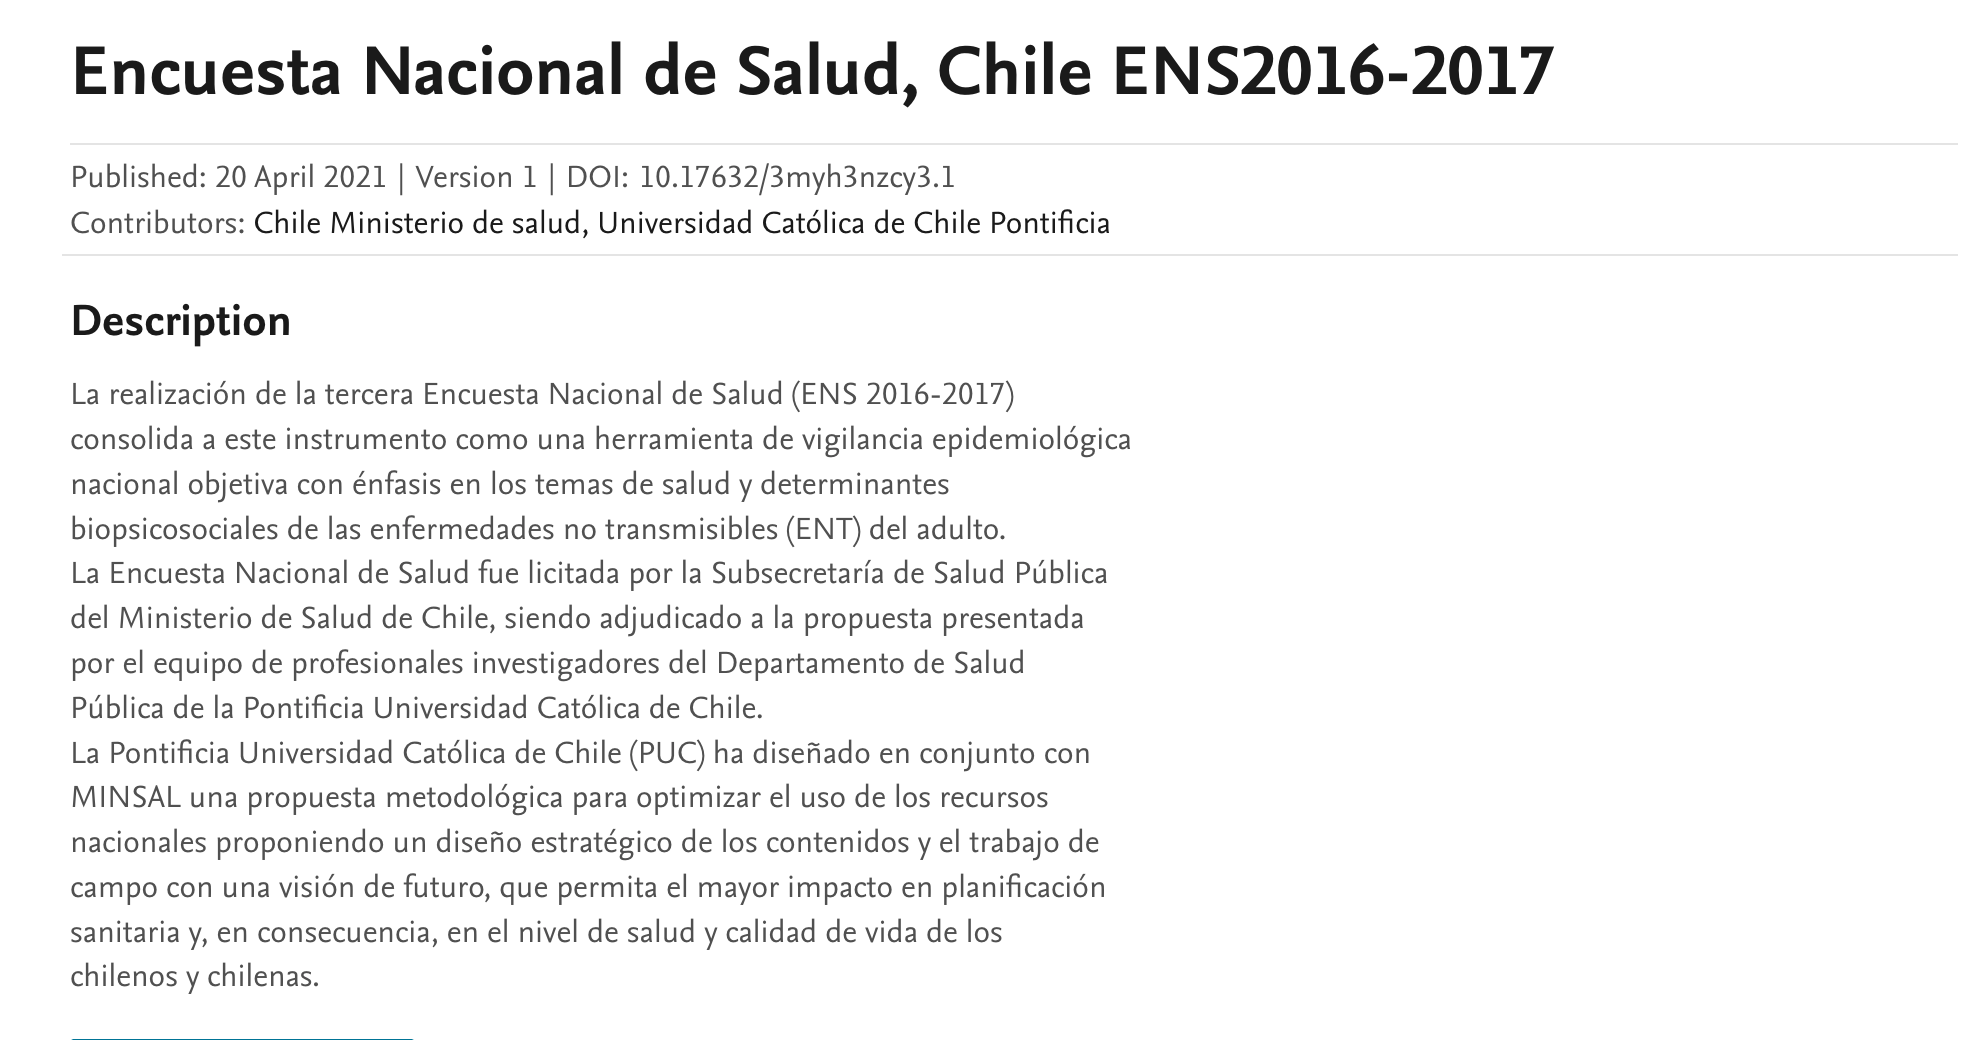</div>

### 3.1 Carga de datos
Tal como se realizo en tallares anteriores, se descargara la base de datos utilizando `wget` y luego se cargara la base de datos en la variable `ens` utilizando la función de pandas `read_spss`.  







In [2]:
# Descargar ENS e installar librerías
!pip install pyreadstat==1.3.0
!wget https://github.com/iHealthInstitute/Talleres_Diplomado_iHealth/raw/refs/heads/main/data/ENS2016-2017.sav

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.2/661.2 kB 5.9 MB/s eta 0:00:00
--2026-03-26 12:07:46--  https://github.com/iHealthInstitute/Talleres_Diplomado_iHealth/raw/refs/heads/main/data/ENS2016-2017.sav
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/iHealthInstitute/Talleres_Diplomado_iHealth/refs/heads/main/data/ENS2016-2017.sav [following]
--2026-03-26 12:07:46--  https://raw.githubusercontent.com/iHealthInstitute/Talleres_Diplomado_iHealth/refs/heads/main/data/ENS2016-2017.sav
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 34441286 (33M) [application/octet-stream]
Saving to: ‘ENS2016

### 3.2 Librerias necesarias
Se importan las librerías necesarias para el análisis y modelado de datos.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 4. Clasificación con Árboles de Decisión


Los árboles de decisión son algoritmos de clasificación supervisada que funcionan a partir de una serie de preguntas binarias sobre las variables disponibles. Cada división del árbol intenta separar lo mejor posible las clases, reduciendo la mezcla de pacientes en cada nodo (impureza).
  * En cada nodo interno se plantea una condición (por ejemplo, ¿edad > 50 años?).
  * Dependiendo de la respuesta (sí/no), el paciente avanza hacia una rama del árbol.
  * Este proceso continúa hasta llegar a una hoja, donde se asigna una clase final (ejemplo: “diabetes = sí”).

Ventajas en salud:
  * Interpretabilidad: se pueden extraer reglas claras en formato if–then.
  * Transparencia clínica: permiten justificar las predicciones a médicos y pacientes.
  * Flexibilidad: pueden manejar variables numéricas y categóricas sin necesidad de transformaciones complejas.

Limitaciones:
  * Sobreajuste: si el árbol crece demasiado, puede memorizar los datos de entrenamiento y perder capacidad de generalización.
  * Inestabilidad: pequeños cambios en los datos pueden generar estructuras de árbol muy diferentes.

Por estas razones, es común limitar la profundidad del árbol, buscando un balance entre interpretabilidad y rendimiento.

En este taller entrenaremos árboles de decisión sobre la ENS 2016-2017, visualizaremos su estructura y aprenderemos a explicar cómo llegan a sus clasificaciones.



#### **Ejercicio 1**
1. Carga la base de datos. HINT: usa pandas.read_spss.
2. Seleccionar la variable `di3` (diagnóstico de diabetes) y limpia sus valores para que solo contenga 0 (no diabetes) y 1 (diabetes).
3. Explorar el dataset:
    * Mostrar dimensiones (.shape).
    * Revisar tipos de variables (.dtypes).
    * Calcular prevalencia de la variable objetivo.
4. Identificar y reportar el porcentaje de valores faltantes por columna.
5. Elimina todas las variables con más del 20% de valores faltantes o de tipo distinto a numérico.
6. Elimina todas las filas con valores faltantes
7. Reporta la distribución de la variable objetivo en la base limpia.
Responde:
    - ¿Cuántas filas y columnas tiene la base limpia?
    - ¿Cuál es la prevalencia de diabetes en la base limpia?


In [4]:
# <CODE> 1. Cargar base
ens = pd.read_spss("ENS2016-2017.sav")

In [5]:
# <CODE> 2. Variable objetivo `di3`
print(ens['di3'].value_counts())
# Convertir Si/No a 1/0
ens['di3'] = ens['di3'].map({'NO': 0, 'SÍ': 1})
print(ens['di3'].value_counts())

di3
NO             5294
SÍ              886
NO RECUERDO      53
Name: count, dtype: int64
di3
0.0    5294
1.0     886
Name: count, dtype: int64


In [11]:
# <CODE> 3. Explorar dataset
# Dimensiones
print("Dimensiones:", ens.shape)
# Tipos de variables
print("Tipos de variables:\n", ens.dtypes)
# Prevalencia de diabetes
prevalencia_diabetes = ens['di3'].mean()
print("Prevalencia de diabetes:", prevalencia_diabetes)

Dimensiones: (6233, 1165)
Tipos de variables:
 IdEncuesta                       float64
FechaInicioF1                    float64
Region                          category
Comuna                            object
Zona                            category
                                  ...   
Cantidad_sintomas_depresivos     float64
Arsenico_µgL                    category
Cadmio_µgL                      category
Mercurio_µgL                    category
Plomo_µgdL                      category
Length: 1165, dtype: object
Prevalencia de diabetes: 0.14336569579288025


In [13]:
#4. Valores faltantes
# Contar cuántos datos vacíos hay por columna
print("% valores faltantes por columna:", ens.isnull().mean()*100)


Valores faltantes por columna: IdEncuesta                       0.000000
FechaInicioF1                    0.000000
Region                           0.000000
Comuna                           0.000000
Zona                             0.000000
                                  ...    
Cantidad_sintomas_depresivos     7.171506
Arsenico_µgL                    42.900690
Cadmio_µgL                      42.884646
Mercurio_µgL                    43.622654
Plomo_µgdL                      42.018290
Length: 1165, dtype: float64


In [14]:
# <CODE> 5. Eliminar variables con >20% faltantes o de tipo distinto a numerorico
# 1. Conservar solo las columnas que son números (enteros o decimales)
ens = ens.select_dtypes(include=['number'])

# 2. Eliminar columnas que tengan más del 20% de datos faltantes (NaN)
limite = 0.8 * len(ens)
ens = ens.dropna(thresh=limite, axis=1)

# Verificamos cuántas columnas quedaron
print(ens.shape)

(6233, 36)


In [16]:
# <CODE> 6. Eliminar filas con NA
ens = ens.dropna()
print(ens.shape)

(4242, 36)


In [19]:
# <CODE> 7. Distribución de diabetes en la base limpia
prevalencia_diabetesfinal =  ens['di3'].value_counts(normalize=True)
print("Prevalencia de diabetes:", prevalencia_diabetesfinal)


Prevalencia de diabetes: di3
0.0    0.85455
1.0    0.14545
Name: proportion, dtype: float64


#### **Ejercicio 2**
 1. Dividir los datos en train/test (80% / 20%). HINT: usa `train_test_split` de sklearn.
 2. Entrenar un `DecisionTreeClassifier` limitando la profundidad (max_depth=3) y el mínimo de muestras por hoja (min_samples_leaf=20).
 3. Reportar métricas de desempeño con `classification_report`.

Responde:
 * ¿qué significa limitar la profundidad y el mínimo de pacientes por hoja?
 * ¿qué métricas son más relevantes en este caso y por qué?
 * ¿cómo se comporta el modelo en train y en test? ¿hay sobreajuste?
 * ¿Qué sucede al cambiar max_depth y min_samples_leaf?

In [20]:
# <CODE> 1. Dividir los datos en train/test (80% / 20%)
from sklearn.model_selection import train_test_split

# 1. Definimos 'X' (todas las variables menos la diabetes) y 'y' (diabetes)
X = ens.drop(columns=['di3'])
y = ens['di3']

# 2. Dividimos: 80% para entrenar y 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Verificamos el tamaño de cada grupo
print(f"Entrenamiento: {len(X_train)} filas")
print(f"Prueba: {len(X_test)} filas")

Entrenamiento: 3393 filas
Prueba: 849 filas


In [21]:
# <CODE> 2. Entrenar un DecisionTreeClassifier limitando la profundidad (max_depth=4) y el mínimo de muestras por hoja (min_samples_leaf=20).
from sklearn.tree import DecisionTreeClassifier

# 1. Crear el modelo con las restricciones solicitadas
modelo_arbol = DecisionTreeClassifier(max_depth=4, min_samples_leaf=20, random_state=42)

# 2. Entrenar el modelo usando los datos de entrenamiento
modelo_arbol.fit(X_train, y_train)

print("¡Modelo entrenado exitosamente!")

¡Modelo entrenado exitosamente!


In [22]:
# <CODE> 3. Reportar métricas de desempeño con classification_report.
from sklearn.metrics import classification_report

# 1. El modelo realiza predicciones sobre los datos que NO ha visto (X_test)
y_pred = modelo_arbol.predict(X_test)

# 2. Generar el reporte comparando la realidad (y_test) con la predicción (y_pred)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.92      0.96      0.94       731
         1.0       0.67      0.47      0.55       118

    accuracy                           0.89       849
   macro avg       0.79      0.71      0.74       849
weighted avg       0.88      0.89      0.89       849



#### **Ejercicio 3**

1. Visualizar el árbol con plot_tree de sklearn, mostrando:
    * Variables usadas en los nodos.
    * Valores de probabilidad de cada clase en las hojas.
    * Colores que indiquen la clase predominante.
2. Exportar las reglas en formato de texto usando export_text.
3. Identificar al menos tres reglas clínicas del árbol y expresarlas en formato if–then:
    * Ejemplo: “Si glucosa > 126 y edad > 60 → mayor probabilidad de diabetes”.

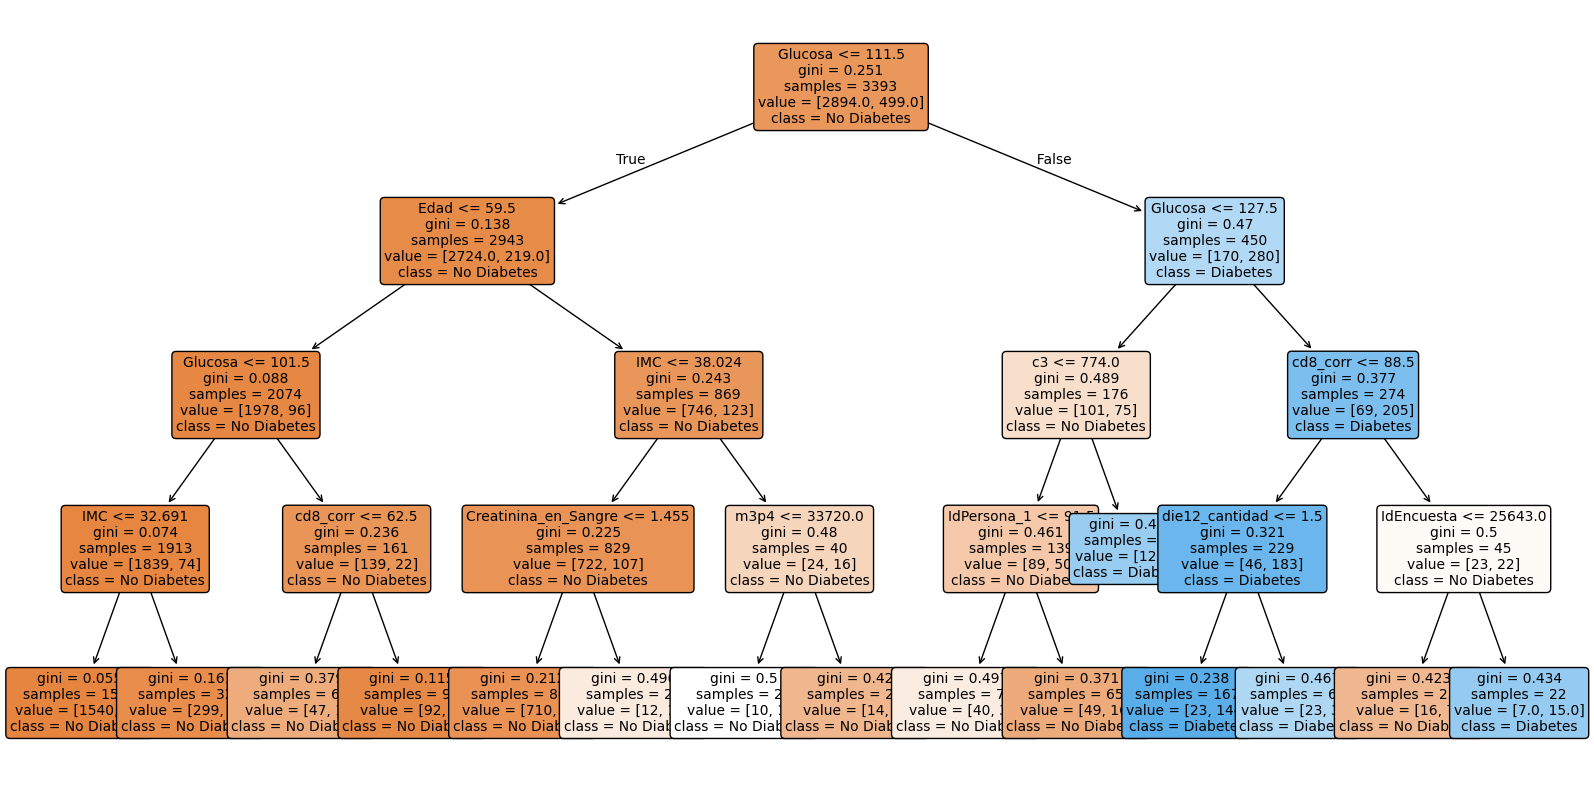

In [23]:
# <CODE> 1. Visualizar el árbol con plot_tree
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 1. Definir el tamaño de la imagen
plt.figure(figsize=(20,10))

# 2. Dibujar el árbol
plot_tree(modelo_arbol,
          feature_names=X.columns,
          class_names=['No Diabetes', 'Diabetes'],
          filled=True,
          rounded=True,
          fontsize=10)

# 3. Mostrar el gráfico
plt.show()

In [24]:
# <CODE> 2. Exportar las reglas en formato de texto usando export_text.
from sklearn.tree import export_text

# 1. Generar las reglas en formato de texto
reglas = export_text(modelo_arbol, feature_names=list(X.columns))

# 2. Imprimir el resultado
print(reglas)

|--- Glucosa <= 111.50
|   |--- Edad <= 59.50
|   |   |--- Glucosa <= 101.50
|   |   |   |--- IMC <= 32.69
|   |   |   |   |--- class: 0.0
|   |   |   |--- IMC >  32.69
|   |   |   |   |--- class: 0.0
|   |   |--- Glucosa >  101.50
|   |   |   |--- cd8_corr <= 62.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- cd8_corr >  62.50
|   |   |   |   |--- class: 0.0
|   |--- Edad >  59.50
|   |   |--- IMC <= 38.02
|   |   |   |--- Creatinina_en_Sangre <= 1.46
|   |   |   |   |--- class: 0.0
|   |   |   |--- Creatinina_en_Sangre >  1.46
|   |   |   |   |--- class: 0.0
|   |   |--- IMC >  38.02
|   |   |   |--- m3p4 <= 33720.00
|   |   |   |   |--- class: 0.0
|   |   |   |--- m3p4 >  33720.00
|   |   |   |   |--- class: 0.0
|--- Glucosa >  111.50
|   |--- Glucosa <= 127.50
|   |   |--- c3 <= 774.00
|   |   |   |--- IdPersona_1 <= 91.50
|   |   |   |   |--- class: 0.0
|   |   |   |--- IdPersona_1 >  91.50
|   |   |   |   |--- class: 0.0
|   |   |--- c3 >  774.00
|   |   |   |--- class: 1.0
|

#### **Ejercicio 4**

1. Calcular matriz de confusión con confusion_matrix. Hint: puede usar `confusion_matrix` y `ConfusionMatrixDisplay` de sklearn.
2. Derivar métricas clínicas clave:
    * Sensibilidad (Recall).
    * Especificidad.
    * Precisión.
    * F1-score.
3. Graficar la curva ROC y calcular el AUC. Hint: puede usar `roc_curve` y `roc_auc_score` de sklearn
4. Responda: ¿qué métrica es más relevante en un contexto de salud pública (ejemplo: detección de diabetes)?

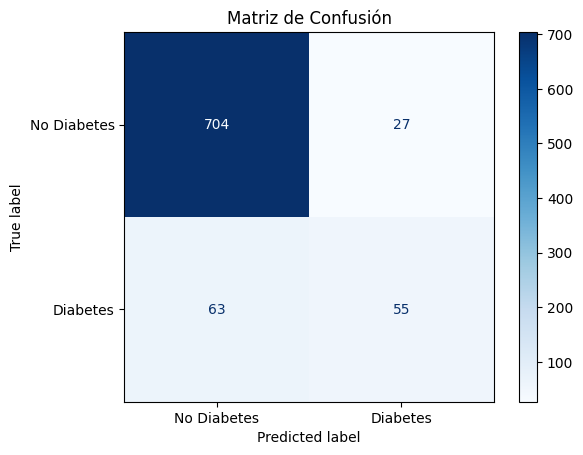

In [25]:
# <CODE> 1. Matriz de confusión
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Calcular la matriz (compara la realidad vs la predicción)
matriz = confusion_matrix(y_test, y_pred)

# 2. Configurar la visualización gráfica
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz,
                                       display_labels=['No Diabetes', 'Diabetes'])

# 3. Dibujar la matriz
visualizacion.plot(cmap='Blues')
plt.title("Matriz de Confusión")
plt.show()

In [26]:
# <CODE> 2. Métricas derivadas de la matriz de confusión
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score

# 1. Calcular cada métrica comparando la realidad (y_test) con la predicción (y_pred)
exactitud = accuracy_score(y_test, y_pred)
sensibilidad = recall_score(y_test, y_pred) # También llamado Recall
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# 2. Mostrar los resultados
print(f"Exactitud (Accuracy): {exactitud:.2f}")
print(f"Sensibilidad (Recall): {sensibilidad:.2f}")
print(f"Precisión: {precision:.2f}")
print(f"Puntuación F1: {f1:.2f}")

Exactitud (Accuracy): 0.89
Sensibilidad (Recall): 0.47
Precisión: 0.67
Puntuación F1: 0.55


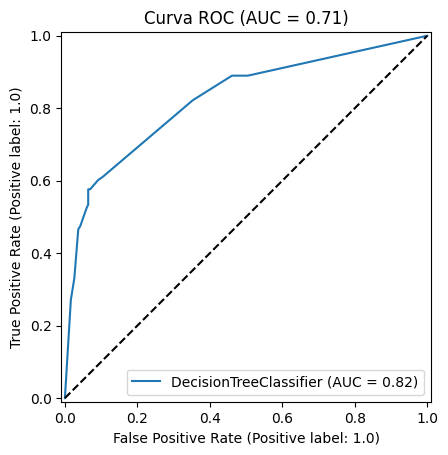

In [27]:
# <CODE> 3. Curva ROC y AUC
from sklearn.metrics import RocCurveDisplay, roc_auc_score

# 1. Calcular el puntaje AUC (Área bajo la curva)
auc = roc_auc_score(y_test, y_pred)

# 2. Graficar la curva ROC
RocCurveDisplay.from_estimator(modelo_arbol, X_test, y_test)
plt.plot([0, 1], [0, 1], "k--") # Línea diagonal de referencia
plt.title(f"Curva ROC (AUC = {auc:.2f})")
plt.show()

#### **Ejercicio 5**
1.Entrenar varios árboles variando la profundidad (max_depth = 2, 4, 6, 10, 20).
2.Para cada árbol, calcular ROC-AUC en test y graficar los resultados.
3.Identificar en qué punto aparece sobreajuste (cuando el rendimiento en train es mucho mayor que en test).
4.Responda: ¿qué balance prefieres en medicina: un modelo más explicable o uno más preciso?

In [28]:
# <CODE> 1. Entrenar varios árboles variando la profundidad (max_depth = 2, 4, 6, 10, 20).
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 1. Lista de profundidades que quieres probar
profundidades = [2, 4, 6, 10, 20]

# 2. Bucle para entrenar y evaluar cada uno
for d in profundidades:
    # Crear y entrenar el modelo con la profundidad 'd'
    modelo = DecisionTreeClassifier(max_depth=d, min_samples_leaf=20, random_state=42)
    modelo.fit(X_train, y_train)

    # Evaluar el desempeño en los datos de prueba
    predicciones = modelo.predict(X_test)
    exactitud = accuracy_score(y_test, predicciones)

    print(f"Profundidad: {d:2} | Exactitud (Accuracy): {exactitud:.4f}")

Profundidad:  2 | Exactitud (Accuracy): 0.8999
Profundidad:  4 | Exactitud (Accuracy): 0.8940
Profundidad:  6 | Exactitud (Accuracy): 0.8893
Profundidad: 10 | Exactitud (Accuracy): 0.8893
Profundidad: 20 | Exactitud (Accuracy): 0.8893


Profundidad:  2 | ROC-AUC: 0.8072
Profundidad:  4 | ROC-AUC: 0.8243
Profundidad:  6 | ROC-AUC: 0.8303
Profundidad: 10 | ROC-AUC: 0.7991
Profundidad: 20 | ROC-AUC: 0.8036


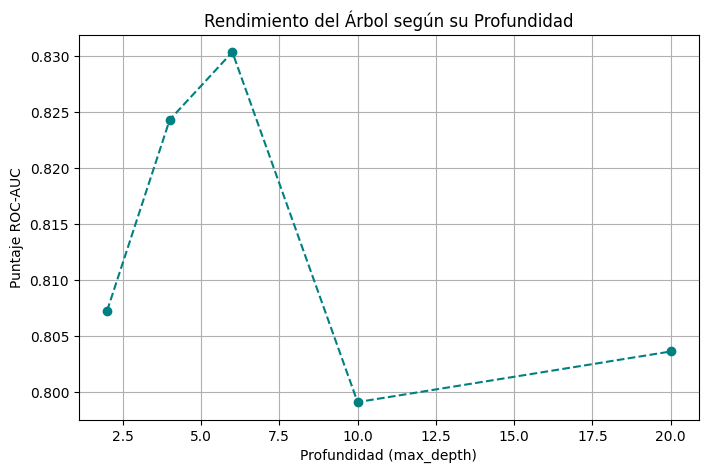

In [29]:
# <CODE> 2. Graficar los resultados
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# 1. Listas para guardar los resultados
profundidades = [2, 4, 6, 10, 20]
resultados_auc = []

# 2. Entrenar y calcular AUC para cada profundidad
for d in profundidades:
    modelo = DecisionTreeClassifier(max_depth=d, min_samples_leaf=20, random_state=42)
    modelo.fit(X_train, y_train)

    # Predecir probabilidades para el cálculo de AUC
    y_pred_auc = modelo.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_pred_auc)
    resultados_auc.append(auc)
    print(f"Profundidad: {d:2} | ROC-AUC: {auc:.4f}")

# 3. Graficar los resultados
plt.figure(figsize=(8, 5))
plt.plot(profundidades, resultados_auc, marker='o', color='teal', linestyle='--')
plt.title("Rendimiento del Árbol según su Profundidad")
plt.xlabel("Profundidad (max_depth)")
plt.ylabel("Puntaje ROC-AUC")
plt.grid(True)
plt.show()

La Meseta o Caída: Si ves que el AUC deja de subir o incluso baja, significa que el árbol se volvió demasiado complejo (sobreajuste).

#### **Ejercicio 6**
1. Vuelva a cargar la `ENS` y cree una nueva variable objetivo a partir del IMC, categorizándola en tres clases:
    * Normal: 18.5 ≤ IMC < 25
    * Sobrepeso: IMC ≥ 25 y < 30
    * Obesidad: IMC ≥ 30

2. Eliminar de las variables predictoras el IMC y cualquier variable no numérica o con más del 20% de valores faltantes.
3. Dividir los datos en entrenamiento (80%) y prueba (20%) de forma estratificada.
4. Entrenar un DecisionTreeClassifier para esta clasificación multiclase (max_depth=4, min_samples_leaf=30).
5. Evaluar el modelo con:
    * Matriz de confusión multiclase.
    * Reporte de métricas (precision, recall, f1-score con promedio macro).
    * Balanced Accuracy.
6. Visualizar el árbol entrenado e interpretar qué variables aparecen en los primeros niveles.
7. Responda: ¿qué diferencias observa entre la clasificación binaria (diabetes) y esta clasificación multiclase (IMC)? ¿Qué desafíos adicionales aparecen en salud pública cuando el problema es multiclase?



In [31]:
# <CODE> 1. Dividir datos en train/test
import pandas as pd
import numpy as np

# 1. Cargar la base de datos nuevamente
ens = pd.read_spss("ENS2016-2017.sav")

# 2. Crear la nueva variable 'estado_nutricional' basada en los rangos de IMC
bins = [18.5, 25, 30, float('inf')]
labels = ['Normal', 'Sobrepeso', 'Obesidad']

ens['estado_nutricional'] = pd.cut(ens['IMC'], bins=bins, labels=labels, right=False)

# 3. Revisar cuántas personas quedaron en cada categoría
print(ens['estado_nutricional'].value_counts())

# 4. Verificar si quedaron valores nulos (personas con IMC < 18.5 o sin dato)
print(f"Valores no categorizados: {ens['estado_nutricional'].isnull().sum()}")

estado_nutricional
Sobrepeso    2087
Obesidad     2056
Normal       1288
Name: count, dtype: int64
Valores no categorizados: 802


In [34]:
# <CODE> 2. Eliminar de las variables predictoras el IMC y cualquier variable no numérica o con más del 20% de valores faltantes.
# 1. Definir la variable objetivo (la que creamos antes)
y = ens['estado_nutricional']

# 2. Crear el conjunto de predictores (X) eliminando el 'imc' original
X = ens.drop(columns=['IMC', 'estado_nutricional'])

# 3. Conservar solo las columnas numéricas
X = X.select_dtypes(include=['number'])

# 4. Eliminar columnas con más del 20% de faltantes
limite = 0.8 * len(X)
X = X.dropna(thresh=limite, axis=1)

# Verificamos cómo quedó nuestra matriz de datos
print(f"Variables predictoras finales: {X.shape[1]}")
print(X.columns.tolist())
ens['estado_nutricional'].value_counts(normalize=True)


Variables predictoras finales: 34
['IdEncuesta', 'FechaInicioF1', 'IdSegmento', 'IdPersona_1', 'Edad', 'c3', 'cd8_corr', 'die7', 'die9', 'die12_cantidad', 'die12e', 'die13_cantidad', 'die13e', 'ts5_aux', 'ts6_aux', 'af2e_esp', 'n_per', 'FechaInicioF2', 'm2p5_1', 'm2p7_1', 'm2p7_2', 'm3p4', 'Creatinina_en_Sangre', 'Glucosa', 'Conglomerado', 'Estrato', 'Fexp_F1p_Corr', 'Fexp_F2p_Corr', 'Fexp_F1F2p_Corr', 'Fexp_EX1p_Corr', 'Fexp_F1F2EX1p_Corr', 'anos_estudio_MINSAL_1', 'Horas_ayuno', 'Cantidad_sintomas_depresivos']


,proportion
estado_nutricional,
Sobrepeso,0.384275
Obesidad,0.378567
Normal,0.237157


In [37]:
# <CODE> 3.  Dividir los datos en entrenamiento (80%) y prueba (20%) de forma estratificada.
from sklearn.model_selection import train_test_split

# Eliminar filas con valores NaN en 'y' (estado_nutricional) y sus correspondientes en 'X'
# Aseguramos que X e y no tengan NaNs antes de la división
valid_indices = y.dropna().index
X = X.loc[valid_indices]
y = y.loc[valid_indices]

# 1. Dividir los datos (80% entrenamiento, 20% prueba)
# El parámetro 'stratify=y' mantiene las proporciones de las 3 categorías
X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.20,
                                                    stratify=y,
                                                    random_state=42)

# 2. Verificar que las proporciones se mantuvieron
print("Proporción en entrenamiento:")
print(y_train.value_counts(normalize=True))

print("\nProporción en prueba:")
print(y_test.value_counts(normalize=True))

Proporción en entrenamiento:
estado_nutricional
Sobrepeso    0.384208
Obesidad     0.378683
Normal       0.237109
Name: proportion, dtype: float64

Proporción en prueba:
estado_nutricional
Sobrepeso    0.384545
Obesidad     0.378105
Normal       0.237351
Name: proportion, dtype: float64


In [39]:
# <CODE> 4. Entrenar un DecisionTreeClassifier para esta clasificación multiclase (max_depth=4, min_samples_leaf=30).
from sklearn.tree import DecisionTreeClassifier

# 1. Crear el modelo con los nuevos parámetros
modelo_nutricional = DecisionTreeClassifier(max_depth=4,
                                            min_samples_leaf=30,
                                            random_state=42)

# 2. Entrenar el modelo con los datos estratificados
modelo_nutricional.fit(X_train, y_train)

print("¡Modelo multiclase entrenado con éxito!")

¡Modelo multiclase entrenado con éxito!


              precision    recall  f1-score   support

      Normal       0.67      0.58      0.62       258
    Obesidad       0.71      0.71      0.71       411
   Sobrepeso       0.54      0.58      0.56       418

    accuracy                           0.63      1087
   macro avg       0.64      0.63      0.63      1087
weighted avg       0.64      0.63      0.63      1087



<Figure size 800x600 with 0 Axes>

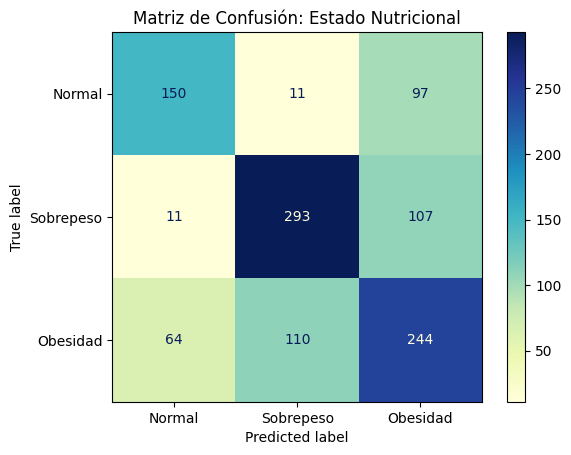

In [41]:
# <CODE> 5. 5. Evaluar el modelo
from sklearn.metrics import classification_report

# 1. Realizar predicciones sobre el grupo de prueba
y_pred_nutricional = modelo_nutricional.predict(X_test)

# 2. Mostrar el reporte detallado por categoría
print(classification_report(y_test, y_pred_nutricional))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Calcular la matriz para las 3 clases
matriz_nutricional = confusion_matrix(y_test, y_pred_nutricional)

# 2. Configurar la visualización
# Usamos las etiquetas en el orden correcto
visualizacion = ConfusionMatrixDisplay(confusion_matrix=matriz_nutricional,
                                       display_labels=['Normal', 'Sobrepeso', 'Obesidad'])

# 3. Dibujar
plt.figure(figsize=(8, 6))
visualizacion.plot(cmap='YlGnBu')
plt.title("Matriz de Confusión: Estado Nutricional")
plt.show()

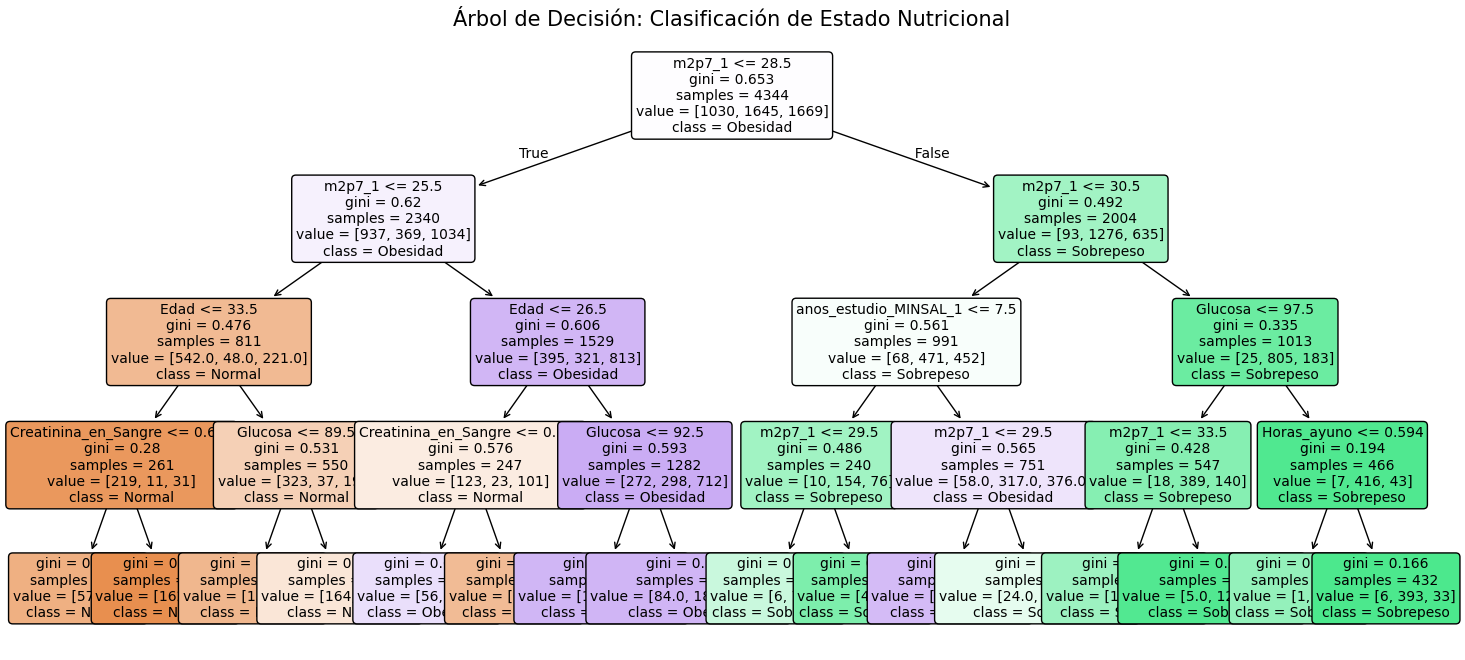

In [44]:
# <CODE> 6. Visualizar el árbol y exportar las reglas
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Configuramos un tamaño de imagen amplio para ver las 3 categorías
plt.figure(figsize=(18,8))

# Dibujamos el árbol con las etiquetas de las clases de peso
plot_tree(modelo_nutricional,
          feature_names=X.columns,
          class_names=['Normal', 'Sobrepeso', 'Obesidad'],
          filled=True,
          rounded=True,
          fontsize=10)

plt.title("Árbol de Decisión: Clasificación de Estado Nutricional", fontsize=15)
plt.show()



In [45]:
#exportar las reglas
from sklearn.tree import export_text

# Generamos las reglas usando los nombres de tus variables médicas
reglas_nutricionales = export_text(modelo_nutricional,
                                   feature_names=list(X.columns))

print("--- REGLAS DEL MODELO NUTRICIONAL ---")
print(reglas_nutricionales)

--- REGLAS DEL MODELO NUTRICIONAL ---
|--- m2p7_1 <= 28.50
|   |--- m2p7_1 <= 25.50
|   |   |--- Edad <= 33.50
|   |   |   |--- Creatinina_en_Sangre <= 0.61
|   |   |   |   |--- class: Normal
|   |   |   |--- Creatinina_en_Sangre >  0.61
|   |   |   |   |--- class: Normal
|   |   |--- Edad >  33.50
|   |   |   |--- Glucosa <= 89.50
|   |   |   |   |--- class: Normal
|   |   |   |--- Glucosa >  89.50
|   |   |   |   |--- class: Normal
|   |--- m2p7_1 >  25.50
|   |   |--- Edad <= 26.50
|   |   |   |--- Creatinina_en_Sangre <= 0.76
|   |   |   |   |--- class: Sobrepeso
|   |   |   |--- Creatinina_en_Sangre >  0.76
|   |   |   |   |--- class: Normal
|   |   |--- Edad >  26.50
|   |   |   |--- Glucosa <= 92.50
|   |   |   |   |--- class: Sobrepeso
|   |   |   |--- Glucosa >  92.50
|   |   |   |   |--- class: Sobrepeso
|--- m2p7_1 >  28.50
|   |--- m2p7_1 <= 30.50
|   |   |--- anos_estudio_MINSAL_1 <= 7.50
|   |   |   |--- m2p7_1 <= 29.50
|   |   |   |   |--- class: Obesidad
|   |   |   |--

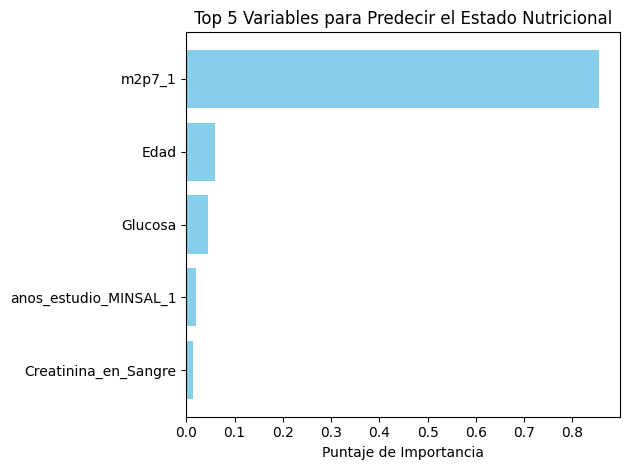

In [46]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Obtener la importancia de cada variable del modelo
importancias = modelo_nutricional.feature_importances_
nombres_variables = X.columns

# 2. Crear un DataFrame para ordenar y filtrar las mejores 5
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancias})
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False).head(5)

# 3. Graficar
plt.barh(df_importancia['Variable'][::-1], df_importancia['Importancia'][::-1], color='skyblue')
plt.xlabel('Puntaje de Importancia')
plt.title('Top 5 Variables para Predecir el Estado Nutricional')
plt.tight_layout()
plt.savefig('importancia_variables.png')